# CSCE 40103 Module 2 - Section 2 Notebook
## Inspecting and Understanding Security Data

This notebook supports **Section 2: Know Your Evidence - Inspecting and Understanding Security Data**.

The purpose is not to train a model yet. The purpose is to inspect a real cybersecurity dataset before preprocessing or modeling.

**Dataset used:** UCI Phishing Websites Dataset. The notebook uses an embedded offline copy of the dataset, so it does **not** need internet access, `pip install`, `ucimlrepo`, `urllib`, or `subprocess`.


## 1. Setup

This notebook is designed for Jupyter Lab environments where internet access or package installation may be restricted.

It uses only:

- `pandas`
- `numpy`
- `matplotlib`
- Python standard library modules

No packages are installed inside the notebook.


In [1]:
from pathlib import Path
from io import StringIO
import base64
import gzip

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

LOCAL_CSV = Path("Phishing.csv")
TARGET_COL = "Result"

print("Setup complete. No package installation or internet access required.")

Matplotlib is building the font cache; this may take a moment.


Setup complete. No package installation or internet access required.


## 2. Embedded Dataset Fallback

This cell stores a compressed copy of the dataset inside the notebook.

How the loader works:

1. If `Phishing.csv` is in the same folder as this notebook, it loads that file.
2. If `Phishing.csv` is not found, it loads the embedded copy.

This prevents failures in restricted Jupyter Lab environments.


In [2]:
EMBEDDED_CSV_GZIP_BASE64 = """
...
irICksk1DAA=
""".strip()

print("Embedded dataset is ready as fallback.")

Embedded dataset is ready as fallback.


## 3. Load the Dataset

The dataset has URL and webpage-related features that are coded mostly as `-1`, `0`, or `1`.

The target column is `Result`:

- `1` means legitimate
- `-1` means phishing


In [3]:
def load_phishing_dataset(local_csv: Path = LOCAL_CSV) -> pd.DataFrame:
    # Load the phishing dataset without internet or package installation.
    if local_csv.exists():
        print(f"Loading local CSV file: {local_csv}")
        loaded_df = pd.read_csv(local_csv)
    else:
        print("Local CSV not found. Loading embedded offline dataset copy...")
        csv_bytes = gzip.decompress(base64.b64decode(EMBEDDED_CSV_GZIP_BASE64))
        csv_text = csv_bytes.decode("utf-8")
        loaded_df = pd.read_csv(StringIO(csv_text))

    return loaded_df


df = load_phishing_dataset()
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Loading local CSV file: Phishing.csv
Dataset loaded successfully.
Shape: (11055, 31)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1


## 4. Confirm the Unit of Observation

Each row represents one website record described by phishing-related URL, HTML, JavaScript, and domain features.

This is important because the eventual prediction task is website-level classification, not user-level, packet-level, or session-level classification.


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Column names:")
print(list(df.columns))

Number of rows: 11055
Number of columns: 31
Column names:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


## 5. Identify Features and Target

Before preprocessing or modeling, separate the target from the input features.

For this dataset:

- Target: `Result`
- Features: all other columns


In [5]:
if TARGET_COL not in df.columns:
    raise ValueError(f"Target column {TARGET_COL!r} was not found. Available columns: {list(df.columns)}")

feature_cols = [col for col in df.columns if col != TARGET_COL]

print("Target column:", TARGET_COL)
print("Number of feature columns:", len(feature_cols))
print("Feature columns:")
print(feature_cols)

Target column: Result
Number of feature columns: 30
Feature columns:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']


## 6. First Structural Inspection

This confirms the dataset shape, first rows, data types, and non-null counts.

This is the step where we ask: Does the dataset look like what the documentation says it should look like?


In [6]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataFrame information:")
df.info()

Dataset shape: (11055, 31)

First 5 rows:


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1



DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                1105

## 7. Structural Validation Checklist

This cell checks for common structural problems:

- Missing target column
- Duplicate column names
- Unexpected data types
- Unexpected target values


In [7]:
duplicate_column_names = df.columns[df.columns.duplicated()].tolist()
dtype_summary = df.dtypes.value_counts()
target_counts = df[TARGET_COL].value_counts(dropna=False).sort_index()

print("Duplicate column names:", duplicate_column_names)
print("\nData type summary:")
print(dtype_summary)
print("\nTarget value counts:")
print(target_counts)
print("\nUnique target values:", sorted(df[TARGET_COL].dropna().unique()))

Duplicate column names: []

Data type summary:
int64    31
Name: count, dtype: int64

Target value counts:
Result
-1    4898
 1    6157
Name: count, dtype: int64

Unique target values: [np.int64(-1), np.int64(1)]


## 8. Missing Values and Duplicate Rows

Even when documentation says there are no missing values, verify it yourself.

Duplicates also matter because they can inflate performance later during train-test splitting.


In [8]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent.round(2)
})

print("Top columns by missing values:")
display(missing_report.head(15))

duplicate_rows = int(df.duplicated().sum())
duplicate_percent = duplicate_rows / len(df) * 100

print("Exact duplicate rows:", duplicate_rows)
print("Exact duplicate row percentage:", round(duplicate_percent, 4), "%")

Top columns by missing values:


,missing_count,missing_percent
having_IP_Address,0,0.0
Submitting_to_email,0,0.0
Statistical_report,0,0.0
Links_pointing_to_page,0,0.0
Google_Index,0,0.0
Page_Rank,0,0.0
web_traffic,0,0.0
DNSRecord,0,0.0
age_of_domain,0,0.0
Iframe,0,0.0


Exact duplicate rows: 5206
Exact duplicate row percentage: 47.0918 %


## 9. Class Distribution

Class distribution is one of the most important early checks in cybersecurity ML.

A high accuracy later may be misleading if one class dominates the dataset.


,class_meaning,count,percent
Result,,,
-1,phishing,4898,44.31
1,legitimate,6157,55.69


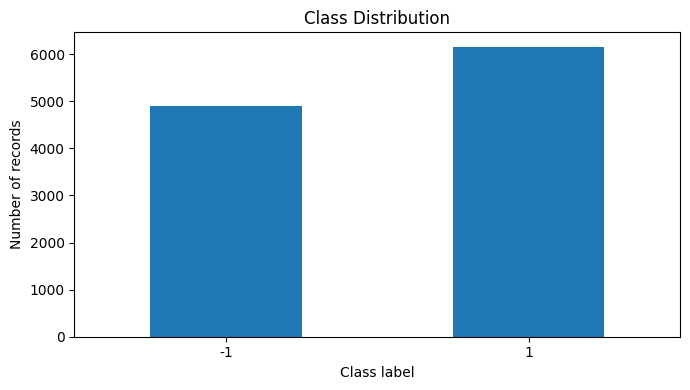

In [9]:
label_counts = df[TARGET_COL].value_counts(dropna=False).sort_index()
label_percent = df[TARGET_COL].value_counts(normalize=True, dropna=False).sort_index() * 100

label_report = pd.DataFrame({
    "class_meaning": ["phishing" if idx == -1 else "legitimate" if idx == 1 else "unknown" for idx in label_counts.index],
    "count": label_counts.values,
    "percent": label_percent.round(2).values
}, index=label_counts.index)

label_report.index.name = TARGET_COL
display(label_report)

ax = label_counts.plot(kind="bar", figsize=(7, 4))
ax.set_title("Class Distribution")
ax.set_xlabel("Class label")
ax.set_ylabel("Number of records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Numerical Feature Inspection

All features in this dataset are integer-coded. Many use `-1`, `0`, and `1` to represent phishing, suspicious, and legitimate signals.

This makes the dataset easy to inspect structurally, but it also means we must understand the coding before interpreting results.


In [10]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
numeric_feature_cols = [col for col in numeric_cols if col != TARGET_COL]

print("Number of numerical feature columns:", len(numeric_feature_cols))
print("Numerical feature columns:")
print(numeric_feature_cols)

numeric_summary = df[numeric_feature_cols].describe().T
numeric_summary["missing"] = df[numeric_feature_cols].isna().sum()
numeric_summary["unique_values"] = df[numeric_feature_cols].nunique()

display(numeric_summary.head(20))

Number of numerical feature columns: 30
Numerical feature columns:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']


,count,mean,std,min,25%,50%,75%,max,missing,unique_values
having_IP_Address,11055.0,0.313795,0.949534,-1.0,-1.0,1.0,1.0,1.0,0,2
URL_Length,11055.0,-0.633198,0.766095,-1.0,-1.0,-1.0,-1.0,1.0,0,3
Shortining_Service,11055.0,0.738761,0.673998,-1.0,1.0,1.0,1.0,1.0,0,2
having_At_Symbol,11055.0,0.700588,0.713598,-1.0,1.0,1.0,1.0,1.0,0,2
double_slash_redirecting,11055.0,0.741474,0.671011,-1.0,1.0,1.0,1.0,1.0,0,2
Prefix_Suffix,11055.0,-0.734962,0.678139,-1.0,-1.0,-1.0,-1.0,1.0,0,2
having_Sub_Domain,11055.0,0.063953,0.817518,-1.0,-1.0,0.0,1.0,1.0,0,3
SSLfinal_State,11055.0,0.250927,0.911892,-1.0,-1.0,1.0,1.0,1.0,0,3
Domain_registeration_length,11055.0,-0.336771,0.941629,-1.0,-1.0,-1.0,1.0,1.0,0,2
Favicon,11055.0,0.628584,0.777777,-1.0,1.0,1.0,1.0,1.0,0,2


## 11. Inspect Allowed Values

Because the features are categorical codes stored as integers, we should inspect the unique values of each feature.

Most features should contain values such as `-1`, `0`, and `1`.


In [11]:
value_report = []
for col in feature_cols:
    unique_values = sorted(df[col].dropna().unique().tolist())
    value_report.append({
        "feature": col,
        "num_unique_values": len(unique_values),
        "unique_values": unique_values
    })

value_report_df = pd.DataFrame(value_report).sort_values(["num_unique_values", "feature"])
display(value_report_df)

,feature,num_unique_values,unique_values
17,Abnormal_URL,2,"[-1, 1]"
24,DNSRecord,2,"[-1, 1]"
8,Domain_registeration_length,2,"[-1, 1]"
9,Favicon,2,"[-1, 1]"
27,Google_Index,2,"[-1, 1]"
11,HTTPS_token,2,"[-1, 1]"
22,Iframe,2,"[-1, 1]"
26,Page_Rank,2,"[-1, 1]"
5,Prefix_Suffix,2,"[-1, 1]"
18,Redirect,2,"[0, 1]"


## 12. Feature Groups by Security Meaning

The feature names suggest several security-related groups.

This grouping is useful for lecture explanation because students can connect features to URL structure, page behavior, and domain reputation.


In [12]:
feature_groups = {
    "Address bar and URL structure": [
        "having_IP_Address", "URL_Length", "Shortining_Service", "having_At_Symbol",
        "double_slash_redirecting", "Prefix_Suffix", "having_Sub_Domain",
        "HTTPS_token"
    ],
    "Domain and reputation": [
        "SSLfinal_State", "Domain_registeration_length", "age_of_domain",
        "DNSRecord", "web_traffic", "Page_Rank", "Google_Index", "Statistical_report"
    ],
    "Page resource and link behavior": [
        "Favicon", "Request_URL", "URL_of_Anchor", "Links_in_tags",
        "Links_pointing_to_page"
    ],
    "HTML, JavaScript, and interaction behavior": [
        "SFH", "Submitting_to_email", "Abnormal_URL", "Redirect", "on_mouseover",
        "RightClick", "popUpWidnow", "Iframe", "port"
    ]
}

for group_name, cols in feature_groups.items():
    existing_cols = [col for col in cols if col in df.columns]
    print(f"\n{group_name} ({len(existing_cols)} features)")
    print(existing_cols)


Address bar and URL structure (8 features)
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'HTTPS_token']

Domain and reputation (8 features)
['SSLfinal_State', 'Domain_registeration_length', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Statistical_report']

Page resource and link behavior (5 features)
['Favicon', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'Links_pointing_to_page']

HTML, JavaScript, and interaction behavior (9 features)
['SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'port']


## 13. Group-Wise EDA by Label

Now compare feature behavior between phishing and legitimate websites.

Because features are coded as integers, group means provide a quick way to see which features differ strongly by class.


Top features with the largest mean difference between classes:


,phishing_mean,legitimate_mean,absolute_difference
SSLfinal_State,-0.479788,0.832223,1.312011
URL_of_Anchor,-0.632095,0.365438,0.997532
web_traffic,-0.033891,0.542797,0.576688
Request_URL,-0.092283,0.408803,0.501086
having_Sub_Domain,-0.209473,0.281468,0.490942
Prefix_Suffix,-1.000000,-0.524119,0.475881
Domain_registeration_length,-0.098408,-0.526393,0.427985
Links_in_tags,-0.330747,0.050999,0.381746
SFH,-0.784198,-0.445834,0.338364
age_of_domain,-0.074724,0.169401,0.244125


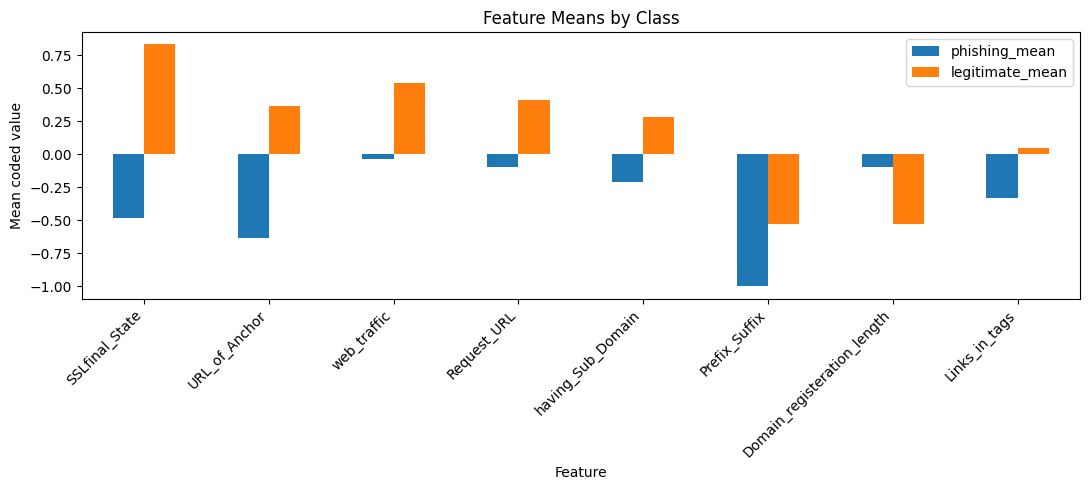

In [13]:
group_means = df.groupby(TARGET_COL)[feature_cols].mean().T
group_means.columns = ["phishing_mean" if col == -1 else "legitimate_mean" if col == 1 else str(col) for col in group_means.columns]

if {"phishing_mean", "legitimate_mean"}.issubset(group_means.columns):
    group_means["absolute_difference"] = (group_means["legitimate_mean"] - group_means["phishing_mean"]).abs()
    group_means = group_means.sort_values("absolute_difference", ascending=False)

print("Top features with the largest mean difference between classes:")
display(group_means.head(15))

plot_features = group_means.head(8).index.tolist()
ax = group_means.loc[plot_features, ["phishing_mean", "legitimate_mean"]].plot(kind="bar", figsize=(11, 5))
ax.set_title("Feature Means by Class")
ax.set_xlabel("Feature")
ax.set_ylabel("Mean coded value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 14. Correlation and Redundancy Inspection

Correlation helps identify redundant features and suspicious relationships.

It does not prove causation. It only measures association.


,SSLfinal_State,URL_of_Anchor,web_traffic,Request_URL,having_Sub_Domain,Prefix_Suffix,Domain_registeration_length,Links_in_tags,SFH,age_of_domain,Page_Rank,having_IP_Address
SSLfinal_State,1.000000,0.535786,0.258768,0.193054,0.267649,0.261391,-0.193622,0.176825,0.171402,0.162809,0.074545,0.071414
URL_of_Anchor,0.535786,1.000000,0.326293,0.177693,0.229491,0.348871,-0.160257,0.136283,0.114311,0.075508,0.099261,0.099847
web_traffic,0.258768,0.326293,1.000000,0.161166,-0.005764,0.110598,-0.134454,0.064548,0.052706,0.089949,0.030984,0.002922
Request_URL,0.193054,0.177693,0.161166,1.000000,0.104857,0.098675,-0.609970,0.067491,0.126661,0.090455,0.055734,0.029773
having_Sub_Domain,0.267649,0.229491,-0.005764,0.104857,1.000000,0.087891,-0.082839,0.093646,0.096089,0.119254,0.120730,-0.080745
Prefix_Suffix,0.261391,0.348871,0.110598,0.098675,0.087891,1.000000,-0.096799,0.100254,0.001326,0.074116,-0.006834,-0.005257
Domain_registeration_length,-0.193622,-0.160257,-0.134454,-0.609970,-0.082839,-0.096799,1.000000,-0.101084,-0.136422,-0.062851,-0.059898,-0.022739
Links_in_tags,0.176825,0.136283,0.064548,0.067491,0.093646,0.100254,-0.101084,1.000000,0.066598,0.078057,-0.006450,0.006212
SFH,0.171402,0.114311,0.052706,0.126661,0.096089,0.001326,-0.136422,0.066598,1.000000,-0.015840,0.001979,-0.010962
age_of_domain,0.162809,0.075508,0.089949,0.090455,0.119254,0.074116,-0.062851,0.078057,-0.015840,1.000000,-0.147194,-0.010446


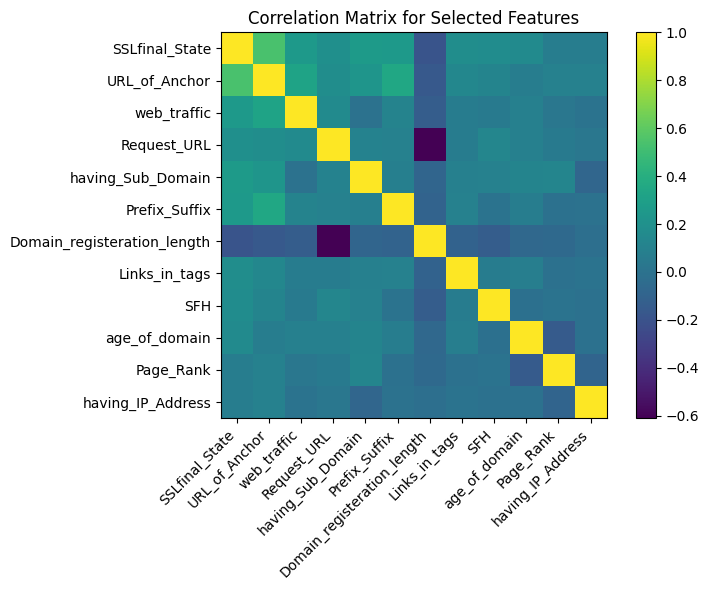

Top high-correlation feature pairs:


Domain_registeration_length  Request_URL                    0.609970
Request_URL                  Domain_registeration_length    0.609970
SSLfinal_State               URL_of_Anchor                  0.535786
URL_of_Anchor                SSLfinal_State                 0.535786
Prefix_Suffix                URL_of_Anchor                  0.348871
URL_of_Anchor                Prefix_Suffix                  0.348871
                             web_traffic                    0.326293
web_traffic                  URL_of_Anchor                  0.326293
SSLfinal_State               having_Sub_Domain              0.267649
having_Sub_Domain            SSLfinal_State                 0.267649
SSLfinal_State               Prefix_Suffix                  0.261391
Prefix_Suffix                SSLfinal_State                 0.261391
web_traffic                  SSLfinal_State                 0.258768
SSLfinal_State               web_traffic                    0.258768
having_Sub_Domain            URL_o

In [14]:
selected_corr_cols = group_means.head(12).index.tolist()

corr_matrix = df[selected_corr_cols].corr()
display(corr_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix)
ax.set_xticks(range(len(selected_corr_cols)))
ax.set_yticks(range(len(selected_corr_cols)))
ax.set_xticklabels(selected_corr_cols, rotation=45, ha="right")
ax.set_yticklabels(selected_corr_cols)
ax.set_title("Correlation Matrix for Selected Features")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

high_corr_pairs = (
    corr_matrix.abs()
    .where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .unstack()
    .dropna()
    .sort_values(ascending=False)
)

print("Top high-correlation feature pairs:")
display(high_corr_pairs.head(20))

## 15. Early Leakage and Caution Scan

This is a simple human-review checklist. It does not prove leakage.

In real projects, leakage is determined by understanding how and when a feature is created.


In [15]:
caution_keywords = [
    "result", "report", "index", "rank", "traffic", "google", "statistical",
    "ssl", "dns", "domain", "age", "registration"
]

columns_to_review = []
for col in df.columns:
    if col == TARGET_COL:
        continue
    if any(keyword in col.lower() for keyword in caution_keywords):
        columns_to_review.append(col)

print("Columns to review carefully before modeling:")
print(columns_to_review)

print("\nInterpretation note:")
print("These columns may be valid features, but they require documentation review because some may depend on external services, timing, reputation, or post-collection information.")

Columns to review carefully before modeling:
['having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']

Interpretation note:
These columns may be valid features, but they require documentation review because some may depend on external services, timing, reputation, or post-collection information.


## 16. Build a Compact Inspection Report

This report summarizes the main inspection findings and saves them as CSV files.

These files can be used as evidence that the dataset was inspected before preprocessing and modeling.


In [16]:
inspection_summary = {
    "dataset_rows": df.shape[0],
    "dataset_columns": df.shape[1],
    "target_column": TARGET_COL,
    "num_features": len(feature_cols),
    "num_missing_values_total": int(df.isna().sum().sum()),
    "num_duplicate_rows": duplicate_rows,
    "phishing_count": int(label_counts.get(-1, 0)),
    "legitimate_count": int(label_counts.get(1, 0)),
    "num_columns_to_review": len(columns_to_review),
}

inspection_summary_df = pd.DataFrame([inspection_summary]).T.reset_index()
inspection_summary_df.columns = ["item", "value"]

display(inspection_summary_df)

inspection_summary_df.to_csv("module2_section2_inspection_summary.csv", index=False)
missing_report.to_csv("module2_section2_missing_value_report.csv")
label_report.to_csv("module2_section2_label_distribution.csv")
group_means.to_csv("module2_section2_groupwise_feature_means.csv")

print("Saved reports:")
print("- module2_section2_inspection_summary.csv")
print("- module2_section2_missing_value_report.csv")
print("- module2_section2_label_distribution.csv")
print("- module2_section2_groupwise_feature_means.csv")

,item,value
0,dataset_rows,11055
1,dataset_columns,31
2,target_column,Result
3,num_features,30
4,num_missing_values_total,0
5,num_duplicate_rows,5206
6,phishing_count,4898
7,legitimate_count,6157
8,num_columns_to_review,10


Saved reports:
- module2_section2_inspection_summary.csv
- module2_section2_missing_value_report.csv
- module2_section2_label_distribution.csv
- module2_section2_groupwise_feature_means.csv


## 17. Section 2 Reflection Questions

Answer these after running the notebook:

1. What does one row represent in this dataset? Each row represents one website record described by phishing-related URL, HTML, JavaScript, and domain features. 
2. What is the target column? What are the feature columns? The target column is `Result`, the feature columns are the attributes of the URL along with the HTML and Javascript attributes.
3. Is the class distribution balanced or imbalanced? Balanced
4. Which features differ most strongly between phishing and legitimate websites?  SSLfinal_State, URL_of_Anchor, and web_traffic
5. Which features should be reviewed carefully before modeling? 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report'
